# Predict variant effects: caQTL & eQTL

A trained Bolero model can score a **DNA variant**: run the model on the reference and the alternate
allele of the same window and take the difference. Because the model is cell-state-conditioned, that
difference is predicted **per cell state**. Bolero exposes this as two tasks:

- **`caqtl_task`** — effect on **chromatin accessibility** (ATAC), summed over a target peak.
- **`eqtl_task`** — effect on **gene expression**, read from the gene-count head (needs a `-Gene` model).

This page shows **what a variant table must contain** and **what the tasks write out**. It is not a
benchmark — we do not correlate the predictions against measured QTL effect sizes (that is the paper's
Fig 3); we just run the tasks and read their outputs.

> **This page uses the `bolerodata` model zoo and QTL collections**, which resolve checkpoints and
> variant tables from the lab data lake — so it runs in the lab environment. The committed outputs
> below are what you would see. (The [prediction page](09_prediction_task.ipynb) shows the
> self-contained raw-config route instead.)

## Setup

In [1]:
import gc
import os

import matplotlib.pyplot as plt
import pandas as pd
import torch

from bolero import init
from bolerodata import MODELS, Zeng2024, GTEx_eqtl_catalog

init(num_cpus=16, object_store_memory_gb=48)

2026-07-13 18:29:44,820	INFO worker.py:1781 -- Started a local Ray instance.


## caQTL — the input table

A caQTL job scores accessibility variants. Each row is one **(variant, peak)** pair. Bolero ships a
fine-mapped adult-brain caQTL set (`Zeng2024`) already in the required format; loading it is the
easiest way to see the schema.

In [2]:
caqtl = Zeng2024.get_qtl_table("Neuron")
print("Zeng2024 Neuron caQTL:", caqtl.shape)
caqtl.head(3)

Zeng2024 Neuron caQTL: (673, 14)


,Chromosome,Start,End,PeakStart,PeakEnd,Ref,Alt,pos2start,beta,variant_id,PIP,peak_id,qtl_id,Tissue
0,chr1,6246183,6770471,6508184,6508520,C,T,262143,0.398701,rs4908554,0.999027,chr1:6508184-6508520,chr1:6508184-6508520+rs4908554,Neuron
1,chr1,32722518,33246806,32984218,32984971,G,C,262143,-0.460641,rs57944861,0.972967,chr1:32984218-32984971,chr1:32984218-32984971+rs57944861,Neuron
2,chr1,48348622,48872910,48610756,48610968,C,A,262143,0.400147,rs320020,0.999999,chr1:48610756-48610968,chr1:48610756-48610968+rs320020,Neuron


The columns the task actually needs (`bolero.tl.predict.task_manager.prepare_qtl_table`):

| column | meaning |
|---|---|
| `Chromosome`, `Start`, `End` | the **524,288 bp Borzoi input window** for this variant |
| `PeakStart`, `PeakEnd` | the target ATAC **peak** the effect is measured over |
| `Ref`, `Alt` | reference / alternate allele |
| `pos2start` | 0-based variant position **relative to `Start`** |
| `variant_id`, `peak_id` | ids; combined into a unique `qtl_id = variant_id + "+" + peak_id` |
| `beta`, `PIP` | *(optional)* measured effect size / fine-mapping probability — carried through, not used for prediction |

You rarely have this ready-made. Here is how to **build it from a plain list of SNVs** — the same
recipe the paper uses: center a 524,288 bp window on each variant and put a small peak around it.

In [3]:
def build_caqtl_table(variant_ids, window=524288, peak_radius=250):
    # variant_ids: list of 'chr_pos_ref_alt' (pos is 1-based)
    rows = []
    for vid in variant_ids:
        chrom, pos, ref, alt = vid.split("_")
        pos0 = int(pos) - 1                       # 0-based variant position
        start = pos0 - window // 2                # center the Borzoi window on the variant
        peak_start, peak_end = pos0 - peak_radius, pos0 + peak_radius
        rows.append({
            "Chromosome": chrom, "Start": start, "End": start + window,
            "PeakStart": peak_start, "PeakEnd": peak_end,
            "Ref": ref, "Alt": alt,
            "pos2start": pos0 - start,            # = window // 2
            "variant_id": vid,
            "peak_id": f"{chrom}:{peak_start}-{peak_end}",
        })
    return pd.DataFrame(rows)

build_caqtl_table(["chr1_1000000_A_G", "chr2_2000000_C_T"])

,Chromosome,Start,End,PeakStart,PeakEnd,Ref,Alt,pos2start,variant_id,peak_id
0,chr1,737855,1262143,999749,1000249,A,G,262144,chr1_1000000_A_G,chr1:999749-1000249
1,chr2,1737855,2262143,1999749,2000249,C,T,262144,chr2_2000000_C_T,chr2:1999749-2000249


## Run the caQTL task

We load the atlas **accessibility** model (`Borzoi10M`, no gene head) conditioned on brain cell
states, and run it on a small slice of the caQTL table. `nosignal=True` runs the model DNA-only, and
`sample_n_pseudobulks=4` keeps the demo to four cell states.

In [4]:
model = MODELS["Borzoi10M"]
model.dataset = "HumanBrainDev"          # multi-dataset model: pick which cell states to use
pred = model.create_predictor(nosignal=True, sample_n_pseudobulks=4)

caqtl_input = caqtl.head(15).reset_index(drop=True)
pred.caqtl_task("caqtl_task_output", caqtl_input, batch_size=8)

Saving batches to /large_storage/zhoulab/hanliu/pkg/liuhlab/bolero/docs/tutorials/prediction/caqtl_task_output/batch
15 regions has finished in /large_storage/zhoulab/hanliu/pkg/liuhlab/bolero/docs/tutorials/prediction/caqtl_task_output/batch
0 regions to compute
Data loader batch size 16


Loading base model weights from: /home/hanliu/data/wmb/model/Borzoi/flashzoi_checkpoints/fold_0.renamed.pt


Model does not have gene_count_output_head, skip
Loading checkpoint from /large_storage/zhoulab/hanliu/250907-MultiDatasetModel/Bolero10M/model/251103-Bolero10M_atac_fold0-final.lora.best_checkpoint.pt


Total time: 0.00s
Inference time: 0.00s or 0.000s per batch
Callback time: 0.00s or 0.000s per batch
(total 0 batches)



## caQTL output

The task writes three tables (rows = `qtl_id`, columns = the predicted cell states):

- **`ref_data.feather`** — predicted accessibility of the **reference** allele over the peak.
- **`alt_data.feather`** — predicted accessibility of the **alternate** allele.
- **`ref_alt_logfc.feather`** — `log2(alt / ref)` = the **cell-state-specific allelic effect**.

In [5]:
out = "caqtl_task_output"
print("output files:", sorted(os.listdir(out)))
logfc = pd.read_feather(f"{out}/ref_alt_logfc.feather")
print("\nref_alt_logfc.feather:", logfc.shape, "(variant-peak x cell state)")
logfc.head()

output files: ['alt_data.feather', 'batch', 'config.joblib.gz', 'ref_alt_logfc.feather', 'ref_data.feather']

ref_alt_logfc.feather: (15, 4) (variant-peak x cell state)


,group16-pseudobulk0,group18-pseudobulk12,group38-pseudobulk15,group6-pseudobulk3
rs4908554+chr1:6508184-6508520,0.031590,0.087719,0.070825,0.021930
rs57944861+chr1:32984218-32984971,-0.588013,-0.954324,-0.251234,-0.476156
rs320020+chr1:48610756-48610968,0.000284,-0.005103,-0.010725,0.080359
rs12044149+chr1:67134895-67135152,-1.681643,-1.463513,-1.504600,-0.515321
rs12742877+chr1:76442296-76442705,0.268877,0.277249,0.127014,0.022570


A single variant's predicted effect across the four cell states — the whole point of a
cell-state-conditioned model is that this can differ by cell type.

[Text(0, 0.5, 'predicted log2(alt/ref)'),
 Text(0.5, 1.0, 'rs57944861+chr1:32984218-32984971')]

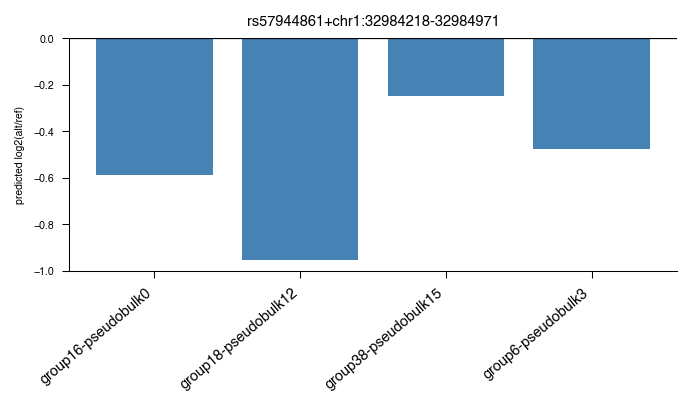

In [6]:
row = logfc.iloc[1]
fig, ax = plt.subplots(figsize=(4.5, 2.6), dpi=150, constrained_layout=True)
ax.bar(range(len(row)), row.values,
       color=["crimson" if v > 0 else "steelblue" for v in row.values])
ax.axhline(0, color="k", lw=0.6)
ax.set_xticks(range(len(row)))
ax.set_xticklabels(row.index, rotation=40, ha="right", fontsize=7)
ax.set(ylabel="predicted log2(alt/ref)", title=row.name)

In [7]:
# free the accessibility model before loading the gene model
del pred, model
gc.collect(); torch.cuda.empty_cache()

## eQTL — the input table

An eQTL job scores expression variants. The idea is identical, but the effect is read from the
**gene-count head**, so the table describes a **(variant, gene)** pair and needs the gene's
coordinates. Bolero ships fine-mapped GTEx eQTL Catalog sets keyed by tissue.

In [8]:
eqtl = GTEx_eqtl_catalog.get_qtl_table("blood")
print("GTEx eQTL Catalog blood:", eqtl.shape)
eqtl[["Chromosome", "Start", "End", "gene_id", "variant_id",
      "GeneStart", "GeneEnd", "Strand", "pos2start", "Ref", "Alt", "pip"]].head(3)

GTEx eQTL Catalog blood: (864, 20)


,Chromosome,Start,End,gene_id,variant_id,GeneStart,GeneEnd,Strand,pos2start,Ref,Alt,pip
0,chr1,1046845,1571133,ENSG00000242485,chr1_1407014_G_A,1401908,1407293,-,164119,C,T,0.928647
1,chr1,1332280,1856568,ENSG00000189339,chr1_1665061_C_T,1659528,1692728,-,191507,G,A,0.999661
2,chr1,1363909,1888197,ENSG00000008128,chr1_1689221_G_A,1702378,1724357,-,198976,C,T,1.000000


Beyond the Borzoi window (`Chromosome/Start/End`), variant (`Ref/Alt/pos2start/variant_id`) and
`gene_id` columns, an eQTL table adds the **gene body** — `GeneStart`, `GeneEnd`, `Strand` — which the
gene-count head integrates over. (For `-` strand genes the alleles are reverse-complemented and
`pos2start` is measured from the window's far end; the shipped tables already encode this.)

## Run the eQTL task

`eqtl_task` needs a model with a gene-count head — `Borzoi10M-Gene`. We condition it on blood cell
states (`ChromiumPBMC`, metadata pseudobulks).

In [9]:
gene_model = MODELS["Borzoi10M-Gene"]
gene_model.dataset = "ChromiumPBMC"
gpred = gene_model.create_predictor(
    nosignal=True, pseudobulk_type="metadata", sample_n_pseudobulks=4
)

eqtl_input = eqtl.head(12).reset_index(drop=True)
gpred.eqtl_task("eqtl_task_output", eqtl_input, batch_size=8)

Saving batches to /large_storage/zhoulab/hanliu/pkg/liuhlab/bolero/docs/tutorials/prediction/eqtl_task_output/batch
0 regions has finished in /large_storage/zhoulab/hanliu/pkg/liuhlab/bolero/docs/tutorials/prediction/eqtl_task_output/batch
12 regions to compute
Data loader batch size 16


Loading base model weights from: /home/hanliu/data/wmb/model/Borzoi/flashzoi_checkpoints/fold_0.renamed.pt


Loading checkpoint from /large_storage/zhoulab/hanliu/250907-MultiDatasetModel/Bolero10M/model/251103-Bolero10M_atac_fold0-gene.lora.best_checkpoint.pt


Dataloader Batch Schema:
- ChromiumPBMC.MetaCell:cov_scale: <class 'torch.Tensor'> torch.Size([8]) torch.float64 cuda:0
- __conditionemb__: <class 'torch.Tensor'> torch.Size([8, 1, 0]) torch.float32 cuda:0
- __conditionemb__:cond0: <class 'torch.Tensor'> torch.Size([4, 1, 0]) torch.float32 cuda:0
- __conditionemb__:cond1: <class 'torch.Tensor'> torch.Size([4, 1, 0]) torch.float32 cuda:0
- __conditionemb__:delta: <class 'torch.Tensor'> torch.Size([4, 1, 0]) torch.float32 cuda:0
- __dna__:alt: <class 'torch.Tensor'> torch.Size([12, 4, 524288]) torch.uint8 cuda:0
- __dna__:ref: <class 'torch.Tensor'> torch.Size([12, 4, 524288]) torch.uint8 cuda:0
- __embedding__: <class 'torch.Tensor'> torch.Size([8, 60]) torch.float32 cuda:0
- __embedding__:cond0: <class 'torch.Tensor'> torch.Size([4, 60]) torch.float32 cuda:0
- __embedding__:cond1: <class 'torch.Tensor'> torch.Size([4, 60]) torch.float32 cuda:0
- __embedding__:delta: <class 'torch.Tensor'> torch.Size([4, 60]) torch.float32 cuda:0
- __yp

## eQTL output

Same three tables, now indexed by **`gene_id + variant_id`** with the values being predicted **gene
expression** (log gene-count) instead of peak accessibility; `ref_alt_logfc` is again the
cell-state-specific allelic effect on expression.

In [10]:
out = "eqtl_task_output"
print("output files:", sorted(os.listdir(out)))
eqtl_logfc = pd.read_feather(f"{out}/ref_alt_logfc.feather")
print("\nref_alt_logfc.feather:", eqtl_logfc.shape, "(gene-variant x cell state)")
eqtl_logfc.head()

output files: ['alt_data.feather', 'batch', 'config.joblib.gz', 'ref_alt_logfc.feather', 'ref_data.feather']

ref_alt_logfc.feather: (12, 4) (gene-variant x cell state)


,CD4__TEM_cell,DC1,HSC_MPP,MAIT_cells
ENSG00000242485+chr1_1407014_G_A,-0.078002,-8.926734e-02,-1.061283e-01,-0.134930
ENSG00000189339+chr1_1665061_C_T,0.000000,-8.599132e-08,-7.948795e-03,0.000000
ENSG00000008128+chr1_1689221_G_A,0.000000,-8.599132e-08,-1.719827e-07,-0.010647
ENSG00000008128+chr1_1733506_G_A,0.000000,-8.599132e-08,-1.719827e-07,-0.010647
ENSG00000268575+chr1_1689221_G_A,0.000000,-1.719827e-07,0.000000e+00,-0.007232


---

Both tasks reduce to the same idea: run the model on the reference and alternate allele and report
the per-cell-state `log2(alt/ref)`. In the paper this predicted effect is correlated against the
measured QTL effect size (`beta`) to benchmark accuracy — here we only needed the tasks to run and
their outputs to be legible.

The next page opens the model up one level further: instead of a single scalar effect, it computes
the **per-base DNA attribution** that explains *why* the model predicts what it does
([attribution](11_attribution_task.ipynb)).